# Taxi V4 using Q learning

Taxi v4 environment description: https://gymnasium.farama.org/environments/toy_text/taxi/

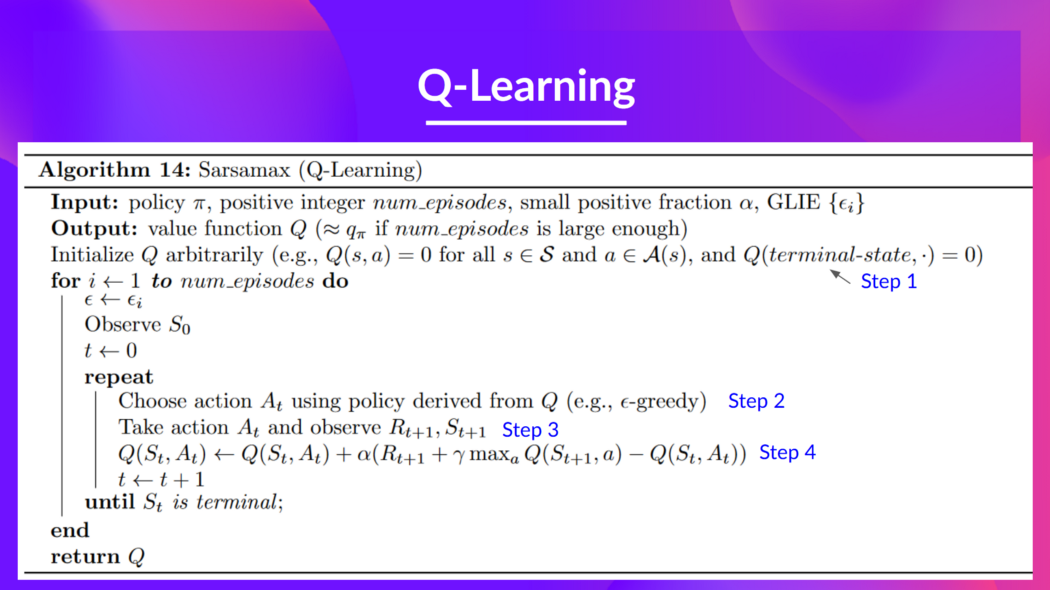

In [1]:
import numpy as np
import gymnasium as gym
import random
import imageio
import os
from tqdm.notebook import tqdm

In [2]:
env = gym.make("Taxi-v4", render_mode="rgb_array")

In [3]:
state_space = env.observation_space.n
print("There are ", state_space, " possible states")

There are  500  possible states


In [4]:
action_space = env.action_space.n
print("There are ", action_space, " possible actions")

There are  6  possible actions


In [5]:
def initialize_q_table(state_space, action_space):
  Qtable = np.zeros((state_space, action_space))
  return Qtable

In [6]:
# Create our Q table with state_size rows and action_size columns (500x6)
Qtable_taxi = initialize_q_table(state_space, action_space)
print(Qtable_taxi)
print("Q-table shape: ", Qtable_taxi .shape)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
Q-table shape:  (500, 6)


In [7]:
# Training parameters
n_training_episodes = 25000   # Total training episodes
learning_rate = 0.7           # Learning rate


# Environment parameters
# env_id = "Taxi-v3"           # Name of the environment
max_steps = 99               # Max steps per episode
gamma = 0.95                 # Discounting rate

# Exploration parameters
max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.05           # Minimum exploration probability
decay_rate = 0.005            # Exponential decay rate for exploration prob

In [8]:
def greedy_policy(Qtable, state):
  return np.argmax(Qtable[state])

def epsilon_greedy_policy(env, Qtable, state, epsilon):
  # Randomly generate a number between 0 and 1
  random_num = random.uniform(0,1)
  # if random_num > greater than epsilon --> exploitation
  if random_num > epsilon:
     action = greedy_policy(Qtable, state)
  else:
    action = env.action_space.sample()
  return action

## Training Algorithm

```
For episode in the total of training episodes:

Reduce epsilon (since we need less and less exploration)
Reset the environment

  For step in max timesteps:    
    Choose the action At using epsilon greedy policy
    Take the action (a) and observe the outcome state(s') and reward (r)
    Update the Q-value Q(s,a) using Bellman equation Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    If done, finish the episode
    Our next state is the new state
```


In [9]:
state, info = env.reset()
state, info

(252, {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

In [10]:
def train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable):
  for episode in tqdm(range(n_training_episodes)):
    # reduce epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)

    state, info = env.reset()
    terminated = False
    truncated = False
    for step in range(max_steps):
      action = epsilon_greedy_policy(env, Qtable, state, epsilon)
      new_state, reward, terminated, truncated, info = env.step(action)

      Qtable[state][action] += learning_rate * (reward + gamma * np.max(Qtable[new_state]) - Qtable[state][action])

      if terminated or truncated:
        break

      state = new_state
  return Qtable

In [11]:
Qtable_taxi = train(n_training_episodes, min_epsilon, max_epsilon, decay_rate, env, max_steps, Qtable_taxi)
Qtable_taxi

  0%|          | 0/25000 [00:00<?, ?it/s]

array([[  0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ],
       [  2.75200369,   3.94947756,   2.75200331,   3.94942513,
          5.20997639,  -5.05052286],
       [  7.93349174,   9.40367562,   7.9334913 ,   9.40367544,
         10.9512375 ,   0.40367562],
       ...,
       [ -2.65639999,   9.40365445,  -3.09563512,  -3.04283367,
         -7.        , -10.68111497],
       [ -5.0762698 ,   3.94947755,   0.34865602,  -5.20947637,
        -10.28384427, -13.4453233 ],
       [ 10.46587779,  14.295     ,  -1.3755    ,  18.        ,
         -7.        ,  -7.        ]])

# Record video

In [12]:
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML
from base64 import b64encode

In [13]:
terminated = False
truncated = False

env = gym.make("Taxi-v4", render_mode="rgb_array")
env = RecordVideo(env, video_folder='./video')

state, info = env.reset(seed=random.randint(0,500))
while not terminated or truncated:
  # Take the action (index) that have the maximum expected future reward given that state
  action = np.argmax(Qtable_taxi[state][:])
  state, reward, terminated, truncated, info = env.step(action) # We directly put next_state = state for recording logic

env.close()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [14]:
mp4 = open('./video/rl-video-episode-0.mp4', 'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML(f'<video width=400 controls><source src="{data_url}" type="video/mp4"></video>')